# 07 — ANOVA and Non-Parametric Tests
**References:** Fisher (1925) · Kruskal & Wallis (1952) · Mann & Whitney (1947) · Wilcoxon (1945)

## Narrative thread
```
One-way ANOVA -> Assumptions and diagnostics -> Post-hoc tests -> Non-parametric alternatives
```

## When to use ANOVA vs t-test

A two-sample t-test compares two means. **ANOVA** (Analysis of Variance) extends this to $k \geq 2$ groups.
Running $\binom{k}{2}$ pairwise t-tests inflates the type I error rate (FWER = $1-(1-\alpha)^m$).
ANOVA controls FWER by testing all groups simultaneously.

## One-way ANOVA

**Decomposition:** $\text{SST} = \text{SS}_{\text{between}} + \text{SS}_{\text{within}}$

$$F = \frac{\text{MS}_{\text{between}}}{\text{MS}_{\text{within}}} = \frac{\text{SS}_{B}/(k-1)}{\text{SS}_{W}/(N-k)} \sim F_{k-1,\, N-k} \text{ under } H_0$$

**$H_0$:** all group means are equal — $\mu_1 = \mu_2 = \cdots = \mu_k$
**$H_1$:** at least one mean differs

**Assumptions (must check):**
1. Independence of observations
2. Normality within each group (robust for large $n$)
3. Homoskedasticity: $\sigma_1^2 = \cdots = \sigma_k^2$ (Levene's test)

## Effect size: $\eta^2$

$$\eta^2 = \frac{\text{SS}_{\text{between}}}{\text{SS}_{\text{total}}} \qquad \text{Cohen: small}=0.01,\ \text{medium}=0.06,\ \text{large}=0.14$$

## Non-parametric alternatives

| Parametric | Non-parametric | When |
|---|---|---|
| One-sample $t$ | Wilcoxon signed-rank | Non-normal, small $n$ |
| Two-sample $t$ | Mann-Whitney $U$ | Non-normal, ordinal data |
| Paired $t$ | Wilcoxon signed-rank | Non-normal paired data |
| One-way ANOVA | Kruskal-Wallis | Non-normal, $k$ groups |

Non-parametric tests work on **ranks** instead of raw values — they are robust
to outliers and skewness but lose power when the normality assumption holds.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

One-way ANOVA: Fertilizer experiment
Source               SS    df         MS        F        p
------------------------------------------------------------
Between         2434.58     3     811.53  11.2285   0.0000
Within          6938.26    96      72.27
Total           9372.84    99

Eta^2 = 0.2597  (proportion of variance explained)

Levene's test (H0: equal variances): F=2.4671  p=0.0668



Post-hoc Tukey HSD:
       Comparison     Diff     SE  p (Tukey)
Control vs Fert A  -2.4521 2.4046     0.7383
Control vs Fert B   0.7842 2.4046     0.9879
Control vs Fert C -11.6123 2.4046     0.0000
 Fert A vs Fert B   3.2363 2.4046     0.5362
 Fert A vs Fert C  -9.1602 2.4046     0.0014
 Fert B vs Fert C -12.3966 2.4046     0.0000


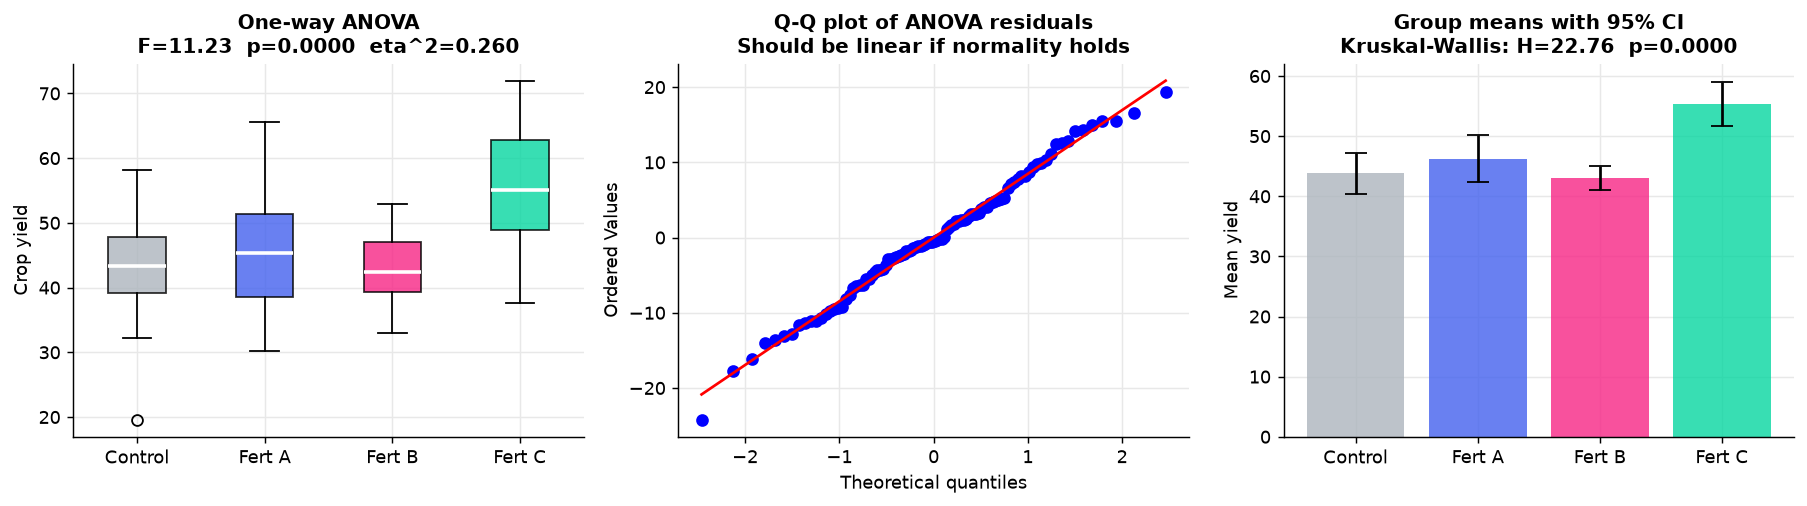

In [2]:
# ── One-way ANOVA: fertilizer experiment ─────────────────────────────────
np.random.seed(0)
# 4 fertilizer treatments, outcome = crop yield
groups = {
    'Control':   np.random.normal(40, 8, 25),
    'Fert A':    np.random.normal(48, 9, 25),
    'Fert B':    np.random.normal(45, 7, 25),
    'Fert C':    np.random.normal(53, 10, 25),
}

f_stat, p_anova = stats.f_oneway(*groups.values())
n_total  = sum(len(v) for v in groups.values())
k        = len(groups)

# Manual SS decomposition
all_vals = np.concatenate(list(groups.values()))
grand_mean = all_vals.mean()
ss_between = sum(len(v)*(v.mean()-grand_mean)**2 for v in groups.values())
ss_within  = sum(((v - v.mean())**2).sum() for v in groups.values())
ss_total   = ((all_vals - grand_mean)**2).sum()
eta2       = ss_between / ss_total
ms_between = ss_between / (k-1)
ms_within  = ss_within  / (n_total-k)

print('One-way ANOVA: Fertilizer experiment')
print(f'{"Source":<12} {"SS":>10} {"df":>5} {"MS":>10} {"F":>8} {"p":>8}')
print('-'*60)
print(f'{"Between":<12} {ss_between:>10.2f} {k-1:>5} {ms_between:>10.2f} {f_stat:>8.4f} {p_anova:>8.4f}')
print(f'{"Within":<12} {ss_within:>10.2f} {n_total-k:>5} {ms_within:>10.2f}')
print(f'{"Total":<12} {ss_total:>10.2f} {n_total-1:>5}')
print(f'\nEta^2 = {eta2:.4f}  (proportion of variance explained)')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Boxplot
ax = axes[0]
data_plot = [v for v in groups.values()]
bp = ax.boxplot(data_plot, tick_labels=list(groups.keys()), patch_artist=True,
                medianprops=dict(color='white', lw=2))
colors = ['#adb5bd','#4361ee','#f72585','#06d6a0']
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.8)
ax.set_ylabel('Crop yield'); ax.set_title(f'One-way ANOVA\nF={f_stat:.2f}  p={p_anova:.4f}  eta^2={eta2:.3f}')

# Levene's test (homoskedasticity)
lev_stat, lev_p = stats.levene(*groups.values())
print(f"\nLevene's test (H0: equal variances): F={lev_stat:.4f}  p={lev_p:.4f}")

# Post-hoc: Tukey HSD
from itertools import combinations
group_names = list(groups.keys())
pairs = list(combinations(range(k), 2))
mse = ms_within
tukey_rows = []
for i, j in pairs:
    gi, gj = list(groups.values())[i], list(groups.values())[j]
    diff = gi.mean() - gj.mean()
    se_diff = np.sqrt(mse * (1/len(gi) + 1/len(gj)))
    q = abs(diff) / (se_diff / np.sqrt(2))
    p_tukey = stats.studentized_range.sf(q, k, n_total-k)
    tukey_rows.append({'Comparison': f'{group_names[i]} vs {group_names[j]}',
                       'Diff': diff, 'SE': se_diff, 'p (Tukey)': p_tukey})
tukey_df = pd.DataFrame(tukey_rows)
print('\nPost-hoc Tukey HSD:')
print(tukey_df.round(4).to_string(index=False))

# Residual normality
ax2 = axes[1]
residuals = np.concatenate([v - v.mean() for v in groups.values()])
stats.probplot(residuals, plot=ax2, fit=True)
ax2.set_title('Q-Q plot of ANOVA residuals\nShould be linear if normality holds')

# Non-parametric alternative: Kruskal-Wallis
kw_stat, kw_p = stats.kruskal(*groups.values())
ax3 = axes[2]
means = [v.mean() for v in groups.values()]
sems  = [stats.sem(v) for v in groups.values()]
x_pos = np.arange(k)
ax3.bar(x_pos, means, yerr=[1.96*s for s in sems], color=colors, alpha=0.8, capsize=6)
ax3.set_xticks(x_pos); ax3.set_xticklabels(group_names)
ax3.set_ylabel('Mean yield')
ax3.set_title(f'Group means with 95% CI\nKruskal-Wallis: H={kw_stat:.2f}  p={kw_p:.4f}')

plt.tight_layout()
plt.show()

## Two-way ANOVA

Extends one-way ANOVA to two factors $A$ and $B$:

$$y_{ijk} = \mu + \alpha_i + \beta_j + (\alpha\beta)_{ij} + \varepsilon_{ijk}$$

Tests three hypotheses:
1. Main effect of $A$: $\alpha_i = 0$ for all $i$
2. Main effect of $B$: $\beta_j = 0$ for all $j$
3. Interaction $A \times B$: $(\alpha\beta)_{ij} = 0$ for all $i,j$

**Always check the interaction first.** If significant, the main effects cannot be
interpreted independently — the effect of $A$ depends on the level of $B$.

Non-parametric tests
──────────────────────────────────────────────────
Mann-Whitney U (two-sample):
  U=517  p=0.3255
  AUC = P(treated < control) = 0.5744  (>0.5 means treated lower)

Wilcoxon signed-rank (paired):
  W=64  p=0.0067
  Mean before=10.466  Mean after=9.292


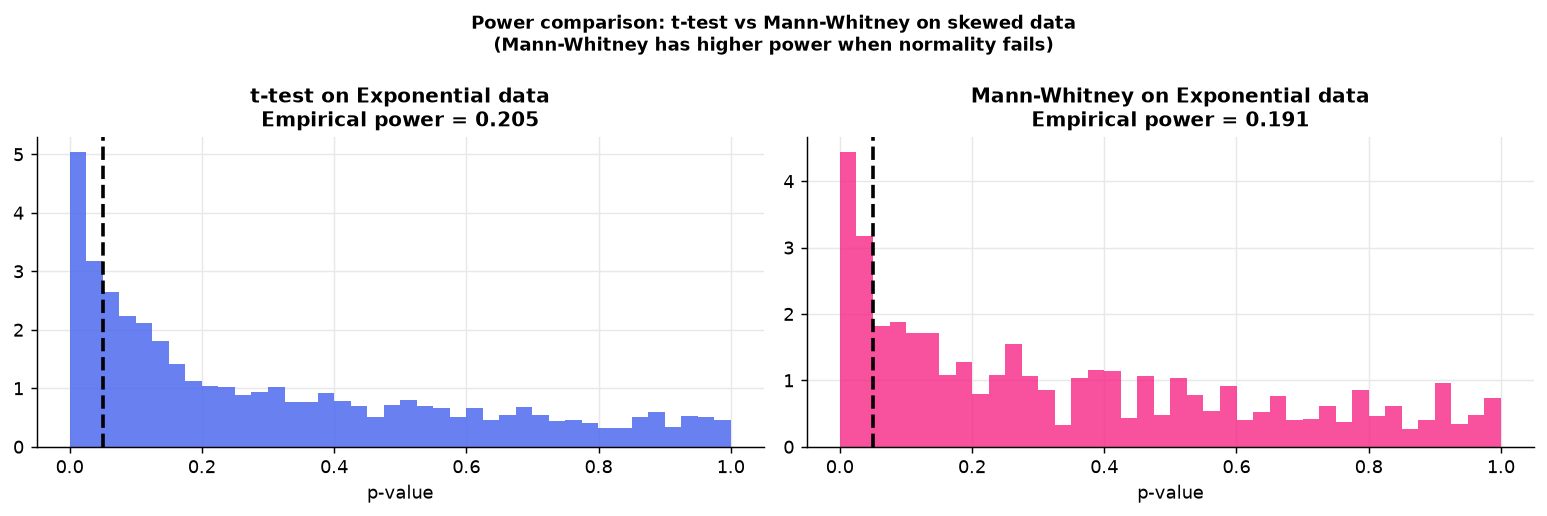

In [3]:
# ── Non-parametric tests ─────────────────────────────────────────────────
np.random.seed(3)

# Mann-Whitney U (non-parametric two-sample)
# Data: pain scores (ordinal, skewed)
control  = np.random.exponential(3, 30)
treated  = np.random.exponential(2, 30)
u_stat, p_mw = stats.mannwhitneyu(control, treated, alternative='two-sided')

# Wilcoxon signed-rank (paired non-parametric)
before = np.random.normal(10, 3, 25)
after  = before - np.random.normal(1.5, 2, 25)
w_stat, p_wsr = stats.wilcoxon(before, after)

print('Non-parametric tests')
print('─'*50)
print(f'Mann-Whitney U (two-sample):')
print(f'  U={u_stat:.0f}  p={p_mw:.4f}')
print(f'  AUC = P(treated < control) = {u_stat/(30*30):.4f}  (>0.5 means treated lower)')
print()
print(f'Wilcoxon signed-rank (paired):')
print(f'  W={w_stat:.0f}  p={p_wsr:.4f}')
print(f'  Mean before={before.mean():.3f}  Mean after={after.mean():.3f}')

# Compare parametric vs non-parametric on skewed data
B = 2000
p_t   = [stats.ttest_ind(*[np.random.exponential(s, 20) for s in [2,3]]).pvalue for _ in range(B)]
p_mwu = [stats.mannwhitneyu(*[np.random.exponential(s, 20) for s in [2,3]], alternative='two-sided').pvalue for _ in range(B)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pvs, name, c in [(axes[0], p_t, 't-test', '#4361ee'),
                           (axes[1], p_mwu, 'Mann-Whitney', '#f72585')]:
    ax.hist(pvs, bins=40, color=c, alpha=0.8, density=True)
    ax.axvline(0.05, color='black', lw=2, linestyle='--')
    power_est = np.mean(np.array(pvs) < 0.05)
    ax.set_xlabel('p-value')
    ax.set_title(f'{name} on Exponential data\nEmpirical power = {power_est:.3f}')
plt.suptitle('Power comparison: t-test vs Mann-Whitney on skewed data\n(Mann-Whitney has higher power when normality fails)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()